## **项目：分析莺尾花种类数据**

### **分析目标**

此数据分析报告的目的是基于鸢尾花的属性数据，分析两种鸢尾花萼片、花瓣的长度和宽度平均值，是否存在显著差异，让我们可以对不同种类鸢尾花的属性特征进行推断

### **简介**

原始数据'Iris.csv'包括两种鸢尾花，每种有50个样本，以及每个样本的一些属性，包括萼片的长度和宽度，花瓣的长度和宽度。  

'Iris.csv'每列的含义如下：  
- id：样本的ID
- SepalLengthCm:萼片的长度（单位为厘米）
- SepalWidthCm:萼片的宽度（单位为厘米）
- PetalLengthCm:花瓣的长度（单位为厘米）
- PetalWidthCm：花瓣的宽度（单位为厘米）
- Species：鸢尾花种类

#### **读取数据**

导入数据分析所需要的库，并通过Pandas的read_csv函数，将原始数据文件Iris.csv里的数据内容，解析为DataFrame并赋值给变量Original_data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
original_data = pd.read_csv("Iris.csv")

In [3]:
original_data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


#### **评估和清理数据**

在这一部分中，我们将对在上一部分建立的original_data DataFrame所包含的数据进行评估和清理。  

主要从两个方面就进行：结构和内容，即整齐度和干净度  

数据的结构性问题指不符合"每个变量为一列，每个观察值为一行，每个类型的观察单位为一个表格"这三个标准；数据的内容性问题包括存在丢失数据，重复数据，无效数据等。  

为了区分开经过清理的数据和原始的数据，我们创建新的变量cleaned_data，让它为original_data复制出的副本，我们之后的清理步骤都将被运用在cleaned_data。

#### **数据整齐度**

In [4]:
cleaned_data = original_data.copy()

从头部的10行数据来看，数据符合"每个变量为一列，每个观察值为一行，每个类型的观察单位为一个表格"，因此不存在结构性问题

#### **数据干净度**

接下来通过info，对数据内容进行大致了解。

In [5]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             100 non-null    int64  
 1   SepalLengthCm  100 non-null    float64
 2   SepalWidthCm   100 non-null    float64
 3   PetalLengthCm  100 non-null    float64
 4   PetalWidthCm   100 non-null    float64
 5   Species        100 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB


从输出结果来看，cleaned_data数据共有100条观察值，不存在缺失值

id表示样本ID，数据类型不应为数字，应为字符串，所以需要进行数据格式转换

In [6]:
cleaned_data["Id"] = cleaned_data["Id"].astype("str")
cleaned_data["Id"]

0       1
1       2
2       3
3       4
4       5
     ... 
95     96
96     97
97     98
98     99
99    100
Name: Id, Length: 100, dtype: object

#### **处理缺失数据**

从info方法的输出结果来看，cleaned_data不存在缺失值，因此不需要对缺失数据进行处理

#### **处理重复数据**

根据数据变量的含义以及内容来看，cleaned_data里的Id是样本的唯一标识符，不应该存在重复，因此查看是否存在重复值

In [7]:
cleaned_data["Id"].duplicated().sum()

np.int64(0)

输出结果为0，说明不存在重复值

#### **处理不一致数据**

不一致数据可能存在于Species变量中，我们要查看是否存在多个不同值指代同一鸢尾花种类的情况

In [8]:
cleaned_data["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Name: count, dtype: int64

从以上输出结果来看，Species只有两种可能的值，Iris-setosa和Iris-versicolor，不存在不一致数据。  

我们可以把这列的类型转为Category，好处是比字符串类型更节约空间，也能表明说值的类型有限

In [9]:
cleaned_data["Species"] = cleaned_data["Species"].astype("category")
cleaned_data["Species"]

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
           ...       
95    Iris-versicolor
96    Iris-versicolor
97    Iris-versicolor
98    Iris-versicolor
99    Iris-versicolor
Name: Species, Length: 100, dtype: category
Categories (2, object): ['Iris-setosa', 'Iris-versicolor']

#### **处理无效数据**

可以通过DataFrame的describe方法，对数值统计信息进行快速了解

In [10]:
cleaned_data.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,100.000000,100.000000,100.000000,100.000000
mean,5.471000,3.094000,2.862000,0.785000
std,0.641698,0.476057,1.448565,0.566288
min,4.300000,2.000000,1.000000,0.100000
25%,5.000000,2.800000,1.500000,0.200000
50%,5.400000,3.050000,2.450000,0.800000
75%,5.900000,3.400000,4.325000,1.300000
max,7.000000,4.400000,5.100000,1.800000


从以上统计信息来看，cleaned_data里不存在脱离现实意义的数值

#### **整理数据**

对数据的整理，与分析方向紧密相关，此次数据分析目标是，基于鸢尾花的属性数据，分析两种鸢尾花萼片、花瓣的长度和宽度平均值，是否存在显著性差异。  

那么我们可以对数据基于Species列，先把各个鸢尾花种类样本数据筛选出来

In [11]:
iris_setosa = cleaned_data.query('Species == "Iris-setosa"')
iris_setosa.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [12]:
len(iris_setosa)

50

In [13]:
iris_versicolor = cleaned_data.query('Species == "Iris-versicolor"')
iris_versicolor.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
50,51,7.0,3.2,4.7,1.4,Iris-versicolor
51,52,6.4,3.2,4.5,1.5,Iris-versicolor
52,53,6.9,3.1,4.9,1.5,Iris-versicolor
53,54,5.5,2.3,4.0,1.3,Iris-versicolor
54,55,6.5,2.8,4.6,1.5,Iris-versicolor


In [14]:
len(iris_versicolor)

50

## **探索数据**

在着手推断统计学分析前，我们可以先借助数据可视化，探索setosa和versicolor这两种鸢尾花的变量特点。  

可视化探索可以帮我们对数据有一个更直观的理解，比如了解数据的分布，发现变量之间的关系，等等，从而为后续的进一步分析提供方向  

针对数值，我们可以直接绘制成对图，利用其中的密度图查看不同变量的分布，以及利用散点图了解变量之间的关系。  

并且，由于此次分析的目的是为了了解不同种类鸢尾花的属性特征是否存在差异，我们可以利用颜色对图表上不同种类类的样本进行分类

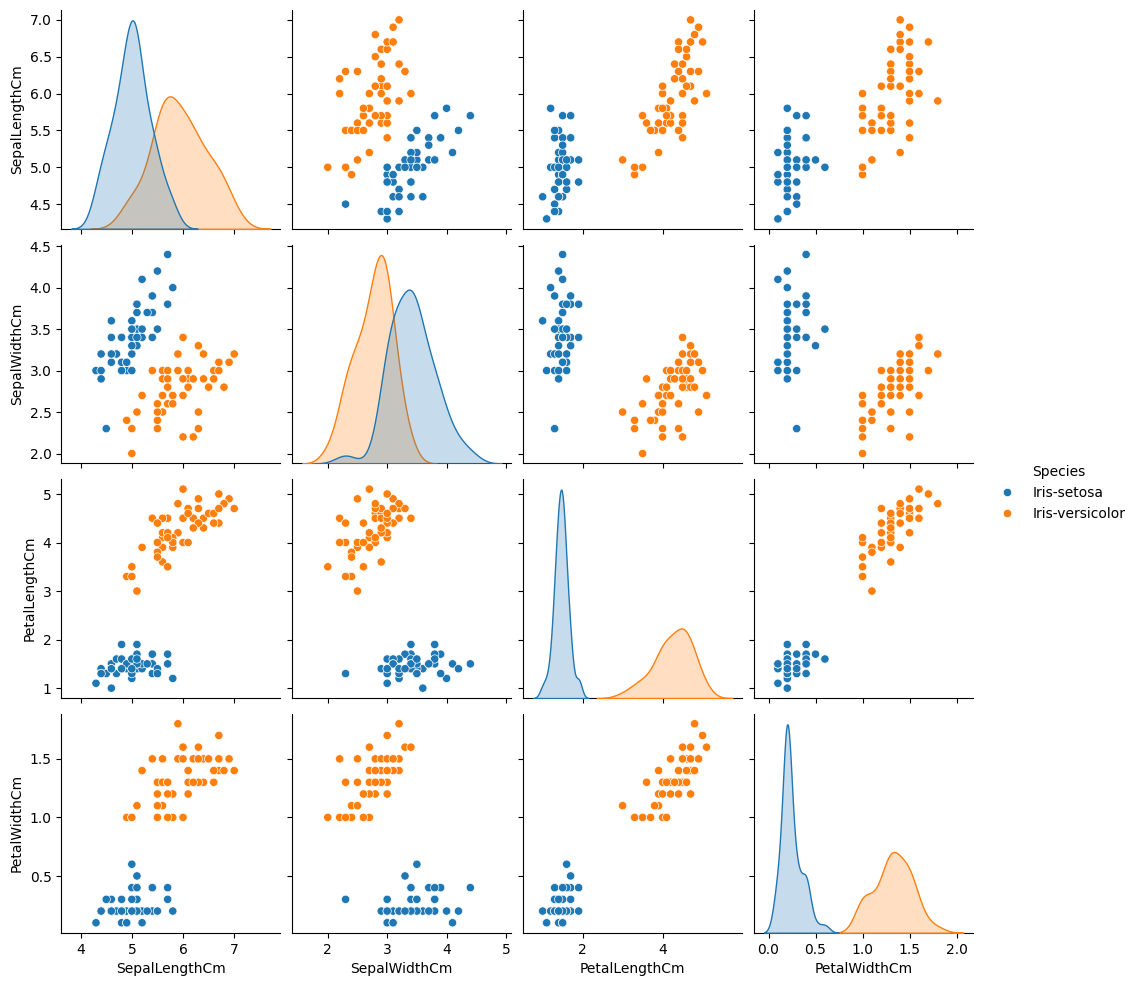

In [15]:
sns.pairplot(cleaned_data, hue="Species")
plt.show()

从以上可以看出，Setosa和Versicolor样本的花瓣长度以及花瓣宽度的分布存在明显数值上的不同，已经可以猜测假设检验的结果，两种鸢尾花的花瓣长度和宽度有统计显著性差异。  

萼片的长度和宽度在分布上存在重叠，暂时无法仅通过图表下结论，需要进行假设检验，来推断总体萼片的长度和宽度之间是否存在差异

### **分析数据**

我们将利用假设检验，依次检验Setosa和Versicolor这两种鸢尾花在萼片、花瓣的长度和宽度平均值方面，是否存在统计显著性差异

In [16]:
from scipy.stats import ttest_ind

#### **分析萼片长度**

Setosa和Versicolor萼片长度如下：

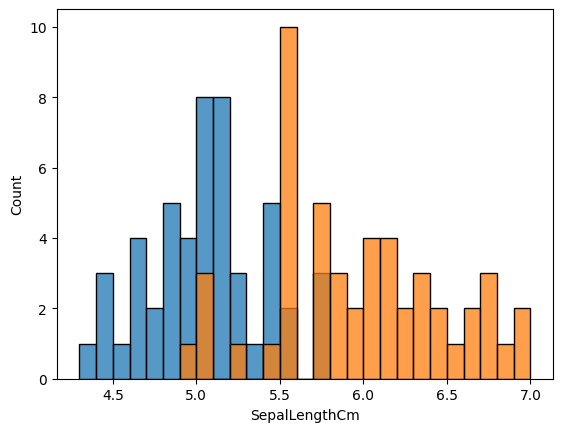

In [17]:
sns.histplot(iris_setosa['SepalLengthCm'], binwidth=0.1)
sns.histplot(iris_versicolor['SepalLengthCm'], binwidth=0.1)
plt.show()

#### **建设假设**

$H_0$: Setosa鸢尾花和Versicolor鸢尾花萼片长度的平均值不存在显著差异区别  

$H_1$: Setosa鸢尾花和Versicolor鸢尾花萼片长度的平均值存在显著差异区别

#### **确认检验是单尾还是双尾**

由于我们只检验平均值是否存在差异，不在乎哪个品种的萼片更长，所以是双尾检验。

#### **确认显著水平**

我们选择0.05作为显著水平

#### **计算t值和p值**

In [18]:
t_stat, p_value = ttest_ind(iris_setosa['SepalLengthCm'], iris_versicolor['SepalLengthCm'])

In [19]:
print(f"t值{t_stat}")
print(f"p值{p_value}")

t值-10.52098626754911
p值8.985235037487079e-18


#### **结论**

由于p值小于显著水平0.05，我们因此拒绝原假设，说明Setosa和Versicolor鸢尾花萼片长度的平均值存在显著区别

#### **分析萼片宽度**

Setosa和Versicolor萼片宽度如下：

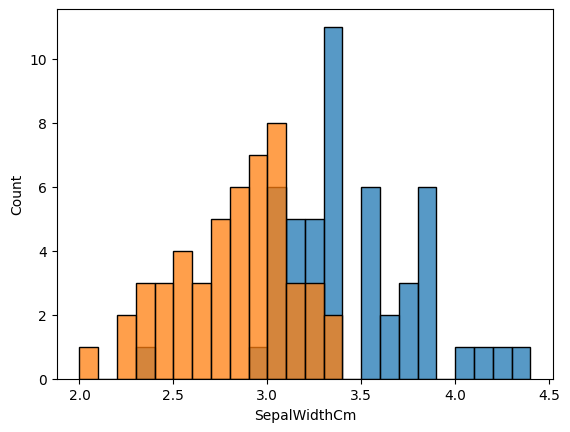

In [26]:
sns.histplot(iris_setosa['SepalWidthCm'], binwidth=0.1)
sns.histplot(iris_versicolor['SepalWidthCm'], binwidth=0.1)
plt.show()

#### **建设假设**

$H_0$: Setosa鸢尾花和Versicolor鸢尾花萼片宽度的平均值不存在显著差异区别  

$H_1$: Setosa鸢尾花和Versicolor鸢尾花萼片宽度的平均值存在显著差异区别

#### **确认检验是单尾还是双尾**

由于我们只检验平均值是否存在差异，不在乎哪个品种的萼片更长，所以是双尾检验。

#### **确认显著水平**

我们选择0.05作为显著水平

#### **计算t值和p值**

In [23]:
t_stat, p_value = ttest_ind(iris_setosa['SepalWidthCm'], iris_versicolor['SepalWidthCm'])

In [24]:
print(f"t值{t_stat}")
print(f"p值{p_value}")

t值9.282772555558111
p值4.362239016010214e-15


#### **结论**

由于p值小于显著水平0.05，我们因此拒绝原假设，说明Setosa鸢尾花和Versicolor鸢尾花萼片宽度的平均值存在显著差异区别

#### **分析花瓣长度**

Setosa和Versicolor花瓣长度如下：

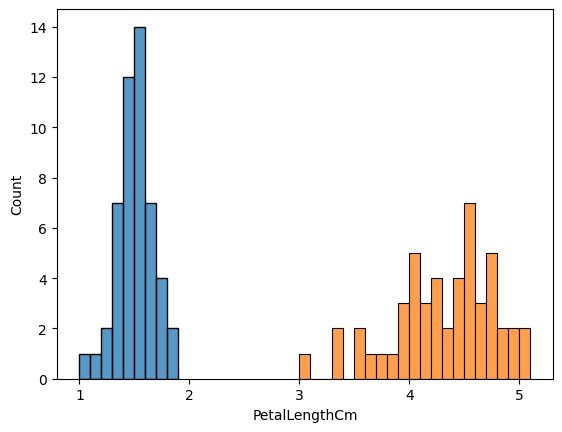

In [27]:
sns.histplot(iris_setosa['PetalLengthCm'], binwidth=0.1)
sns.histplot(iris_versicolor['PetalLengthCm'], binwidth=0.1)
plt.show()

#### **建设假设**

$H_0$: Setosa鸢尾花和Versicolor鸢尾花花瓣长度的平均值不存在显著差异区别  

$H_1$: Setosa鸢尾花和Versicolor鸢尾花花瓣长度的平均值存在显著差异区别

#### **确认检验是单尾还是双尾**

由于我们只检验平均值是否存在差异，不在乎哪个品种的萼片更长，所以是双尾检验。

#### **确认显著水平**

我们选择0.05作为显著水平

#### **计算t值和p值**

In [28]:
t_stat, p_value = ttest_ind(iris_setosa['PetalLengthCm'], iris_versicolor['PetalLengthCm'])

In [29]:
print(f"t值{t_stat}")
print(f"p值{p_value}")

t值-39.46866259397272
p值5.717463758170621e-62


#### **结论**

由于p值小于显著水平0.05，我们因此拒绝原假设，说明Setosa鸢尾花和Versicolor鸢尾花花瓣长度的平均值存在显著差异区别

#### **分析花瓣宽度**

Setosa和Versicolor花瓣宽度如下：

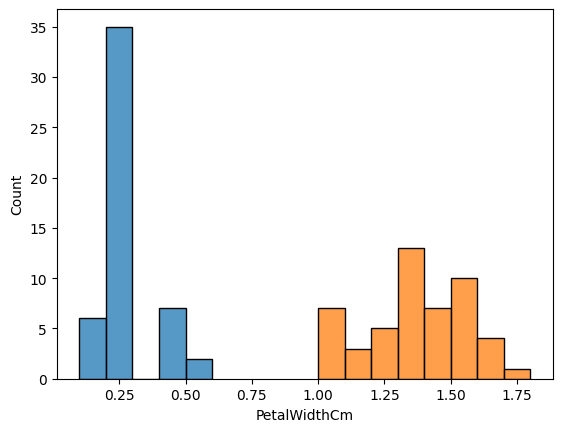

In [30]:
sns.histplot(iris_setosa['PetalWidthCm'], binwidth=0.1)
sns.histplot(iris_versicolor['PetalWidthCm'], binwidth=0.1)
plt.show()

#### **建设假设**

$H_0$: Setosa鸢尾花和Versicolor鸢尾花花瓣宽度的平均值不存在显著差异区别  

$H_1$: Setosa鸢尾花和Versicolor鸢尾花花瓣宽度的平均值存在显著差异区别

#### **确认检验是单尾还是双尾**

由于我们只检验平均值是否存在差异，不在乎哪个品种的萼片更长，所以是双尾检验。

#### **确认显著水平**

我们选择0.05作为显著水平

#### **计算t值和p值**

In [31]:
t_tats, p_value = ttest_ind(iris_setosa['PetalWidthCm'], iris_versicolor['PetalWidthCm'])

In [32]:
print(f"t值{t_tats}")
print(f"p值{p_value}")

t值-34.01237858829048
p值4.589080615710866e-56


#### **结论**

由于p值小于显著水平0.05，我们因此拒绝原假设，说明Setosa鸢尾花和Versicolor鸢尾花花瓣宽度的平均值存在显著差异区别

#### **总体结论**

通过推论统计学的计算过程，我们发现，Setosa鸢尾花和Versicolor鸢尾花萼片、花瓣的长度和宽度平均值，均存在具有统计显著性的差异